In [114]:
import pandas as pd
from math import ceil
import matplotlib.pyplot as plt
from matplotlib import cm

df = pd.read_csv('../Neuronales_Netz/Fahrradzaehlung_komplett_rolling_mean_int.csv',
                 sep=',')
df['time'] = pd.to_datetime(df['time'])
df['days'] = df['time'].dt.date

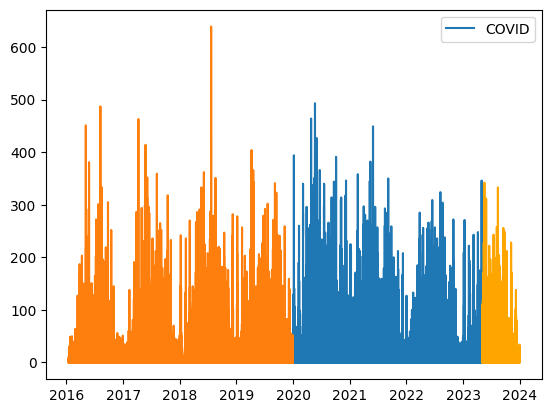

In [126]:
from datetime import datetime
df.index = df['time']
start_date = datetime(2019, 12, 31)
end_date = datetime(2023, 5, 5)
final_date=datetime(2023, 12, 31)
plt.plot(df.loc[start_date:end_date, 'estermannufer'], label='COVID')
plt.plot(df.loc[:start_date, 'estermannufer'])
plt.plot(df.loc[end_date:final_date, 'estermannufer'], color='orange')
plt.legend()
plt.show()

In [116]:
display(df)

,time,bruehler_straße,estermannufer,kennedybruecke,nordbruecke,suedbruecke,rhenusallee,von_sandt_ufer,weg_auf_dem_damm,wilhelm_spiritus_ufer,days
time,,,,,,,,,,,
2016-01-16 00:00:00,2016-01-16 00:00:00,5,0,36,1,3,5,2,3,1,2016-01-16
2016-01-16 01:00:00,2016-01-16 01:00:00,4,0,44,3,4,4,2,3,4,2016-01-16
2016-01-16 02:00:00,2016-01-16 02:00:00,0,0,26,3,3,3,0,3,2,2016-01-16
2016-01-16 03:00:00,2016-01-16 03:00:00,3,0,15,0,0,0,0,0,0,2016-01-16
2016-01-16 04:00:00,2016-01-16 04:00:00,1,0,22,3,1,2,0,0,1,2016-01-16
...,...,...,...,...,...,...,...,...,...,...,...
2023-12-31 19:00:00,2023-12-31 19:00:00,13,0,146,12,22,25,5,18,11,2023-12-31
2023-12-31 20:00:00,2023-12-31 20:00:00,13,0,99,15,10,25,2,10,13,2023-12-31
2023-12-31 21:00:00,2023-12-31 21:00:00,13,0,69,5,9,25,6,12,13,2023-12-31


In [117]:
df['sum'] = df.sum(axis=1, numeric_only=True)

In [118]:
df

,time,bruehler_straße,estermannufer,kennedybruecke,nordbruecke,suedbruecke,rhenusallee,von_sandt_ufer,weg_auf_dem_damm,wilhelm_spiritus_ufer,days,sum
time,,,,,,,,,,,,
2016-01-16 00:00:00,2016-01-16 00:00:00,5,0,36,1,3,5,2,3,1,2016-01-16,56
2016-01-16 01:00:00,2016-01-16 01:00:00,4,0,44,3,4,4,2,3,4,2016-01-16,68
2016-01-16 02:00:00,2016-01-16 02:00:00,0,0,26,3,3,3,0,3,2,2016-01-16,40
2016-01-16 03:00:00,2016-01-16 03:00:00,3,0,15,0,0,0,0,0,0,2016-01-16,18
2016-01-16 04:00:00,2016-01-16 04:00:00,1,0,22,3,1,2,0,0,1,2016-01-16,30
...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-31 19:00:00,2023-12-31 19:00:00,13,0,146,12,22,25,5,18,11,2023-12-31,252
2023-12-31 20:00:00,2023-12-31 20:00:00,13,0,99,15,10,25,2,10,13,2023-12-31,187
2023-12-31 21:00:00,2023-12-31 21:00:00,13,0,69,5,9,25,6,12,13,2023-12-31,152


In [119]:
def get_season(date):
    month = date.month
    if month in [3, 4, 5]:
        return 'Frühling'
    elif month in [6, 7, 8]:
        return 'Sommer'
    elif month in [9, 10, 11]:
        return 'Herbst'
    else:
        return 'Winter'


df['season'] = df['days'].apply(get_season)

In [120]:
df

,time,bruehler_straße,estermannufer,kennedybruecke,nordbruecke,suedbruecke,rhenusallee,von_sandt_ufer,weg_auf_dem_damm,wilhelm_spiritus_ufer,days,sum,season
time,,,,,,,,,,,,,
2016-01-16 00:00:00,2016-01-16 00:00:00,5,0,36,1,3,5,2,3,1,2016-01-16,56,Winter
2016-01-16 01:00:00,2016-01-16 01:00:00,4,0,44,3,4,4,2,3,4,2016-01-16,68,Winter
2016-01-16 02:00:00,2016-01-16 02:00:00,0,0,26,3,3,3,0,3,2,2016-01-16,40,Winter
2016-01-16 03:00:00,2016-01-16 03:00:00,3,0,15,0,0,0,0,0,0,2016-01-16,18,Winter
2016-01-16 04:00:00,2016-01-16 04:00:00,1,0,22,3,1,2,0,0,1,2016-01-16,30,Winter
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-31 19:00:00,2023-12-31 19:00:00,13,0,146,12,22,25,5,18,11,2023-12-31,252,Winter
2023-12-31 20:00:00,2023-12-31 20:00:00,13,0,99,15,10,25,2,10,13,2023-12-31,187,Winter
2023-12-31 21:00:00,2023-12-31 21:00:00,13,0,69,5,9,25,6,12,13,2023-12-31,152,Winter


In [121]:
seasonal = df.groupby('season')
key_ordered= ['Frühling', 'Sommer', 'Herbst', 'Winter']
seasonal['sum'].sum()

season
Frühling    15804576
Herbst      14121577
Sommer      18703257
Winter       9664074
Name: sum, dtype: int64

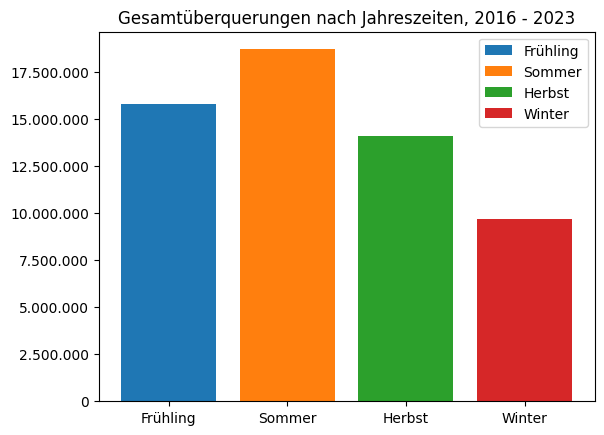

In [122]:
fig, ax = plt.subplots()
import matplotlib.ticker as ticker
for key in key_ordered:
    ax.bar(key, seasonal.get_group(key)['sum'].sum(), label=key, align='center')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}".replace(",", ".")))
plt.title('Gesamtüberquerungen nach Jahreszeiten, 2016 - 2023')
plt.legend()
plt.show()

In [123]:
df['month'] = df['time'].dt.month
df

,time,bruehler_straße,estermannufer,kennedybruecke,nordbruecke,suedbruecke,rhenusallee,von_sandt_ufer,weg_auf_dem_damm,wilhelm_spiritus_ufer,days,sum,season,month
time,,,,,,,,,,,,,,
2016-01-16 00:00:00,2016-01-16 00:00:00,5,0,36,1,3,5,2,3,1,2016-01-16,56,Winter,1
2016-01-16 01:00:00,2016-01-16 01:00:00,4,0,44,3,4,4,2,3,4,2016-01-16,68,Winter,1
2016-01-16 02:00:00,2016-01-16 02:00:00,0,0,26,3,3,3,0,3,2,2016-01-16,40,Winter,1
2016-01-16 03:00:00,2016-01-16 03:00:00,3,0,15,0,0,0,0,0,0,2016-01-16,18,Winter,1
2016-01-16 04:00:00,2016-01-16 04:00:00,1,0,22,3,1,2,0,0,1,2016-01-16,30,Winter,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-31 19:00:00,2023-12-31 19:00:00,13,0,146,12,22,25,5,18,11,2023-12-31,252,Winter,12
2023-12-31 20:00:00,2023-12-31 20:00:00,13,0,99,15,10,25,2,10,13,2023-12-31,187,Winter,12
2023-12-31 21:00:00,2023-12-31 21:00:00,13,0,69,5,9,25,6,12,13,2023-12-31,152,Winter,12


In [124]:
monthly = df.groupby('month')
monthly['sum'].sum()

month
1     3095350
2     3503907
3     4472361
4     5151422
5     6180793
6     6154334
7     6210535
8     6338388
9     5636629
10    4590456
11    3894492
12    3064817
Name: sum, dtype: int64

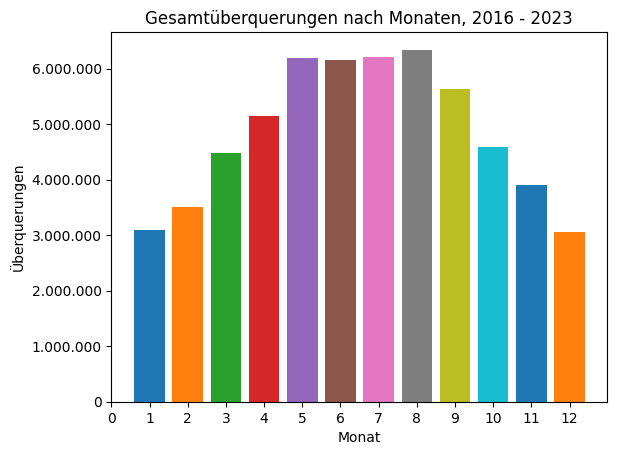

In [127]:
fig, ax = plt.subplots()
import matplotlib.ticker as ticker
import numpy as np
for name, group in monthly:
    ax.bar(name, group['sum'].sum(), label=name, align='center')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}".replace(",", ".")))
x = np.arange(0, 13, 1)
plt.title('Gesamtüberquerungen nach Monaten, 2016 - 2023')
plt.xticks(x)
plt.xlabel('Monat')
plt.ylabel('Überquerungen')
plt.show()